In [20]:
import pandas as pd 
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv('X_selected.csv')

In [31]:
df.head(10)

,eccentricity,circularity,cell_area_px,lobularity_score,nucleus_area_pct,perimeter_px,membrane_smoothness,cell_diameter_um,mean_r,stain_intensity,hemoglobin_g_dl,rbc_count_millions_per_ul,patient_age_group,mcv_fl,mean_b,patient_sex,hematocrit_pct
0,0.529,0.563,445,6.6,58.8,90,0.800,15.18,215,0.555,11.7,4.44,1,85.5,160,0,43.4
1,0.443,0.859,383,6.3,73.6,61,0.737,16.47,189,0.692,13.9,4.90,1,92.5,169,1,42.2
2,0.407,0.781,418,3.2,55.5,52,0.790,13.41,193,0.593,16.1,5.72,0,76.3,203,1,39.2
3,0.167,0.880,217,1.0,0.0,39,0.937,7.36,227,0.509,14.6,3.42,0,92.3,118,0,54.1
4,0.158,1.000,147,1.0,0.0,50,0.925,7.53,239,0.607,14.6,5.36,1,83.9,113,1,36.7
5,0.351,0.777,551,1.0,57.8,96,0.848,14.97,189,0.805,14.9,2.70,1,93.7,170,0,37.2
6,0.312,0.559,579,1.0,63.3,80,0.696,15.63,196,0.570,14.7,4.01,0,80.9,176,0,39.6
7,0.045,0.820,277,1.0,78.3,63,0.886,9.15,191,0.789,10.9,4.04,2,88.5,204,1,38.4
8,0.761,0.288,449,1.1,92.9,78,0.440,10.10,164,0.612,13.8,5.07,0,80.6,218,1,43.6
9,0.575,0.785,556,1.0,64.1,95,0.723,16.97,204,0.660,9.9,4.36,2,66.3,201,1,43.4


In [32]:
df.dtypes

eccentricity                 float64
circularity                  float64
cell_area_px                   int64
lobularity_score             float64
nucleus_area_pct             float64
perimeter_px                   int64
membrane_smoothness          float64
cell_diameter_um             float64
mean_r                         int64
stain_intensity              float64
hemoglobin_g_dl              float64
rbc_count_millions_per_ul    float64
patient_age_group              int64
mcv_fl                       float64
mean_b                         int64
patient_sex                    int64
hematocrit_pct               float64
dtype: object

## Implement Isolation Forest 

In [33]:
from sklearn.ensemble import IsolationForest

In [34]:
iso = IsolationForest(contamination=0.01, random_state= 42) 
X = df.select_dtypes(include = 'number')
iso.fit(X)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [35]:
### prediction results 
pred = iso.predict(X)

In [36]:
### calculate anomaly score 
scores = iso.score_samples(X)

In [37]:
df['anomaly'] = pred 
df['anomaly_score'] = scores 

In [38]:
df['anomaly'].value_counts()

anomaly
 1    5821
-1      59
Name: count, dtype: int64

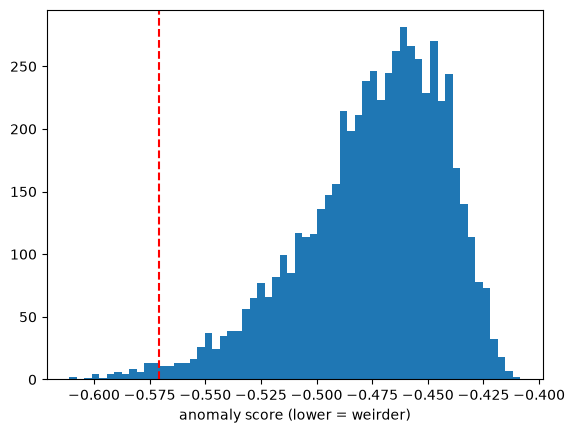

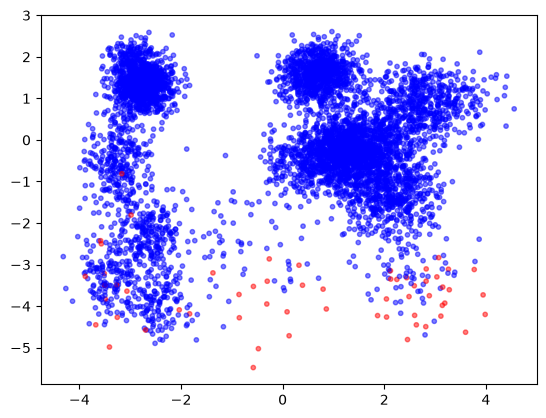

In [47]:
# a) score distribution — works for any number of features
plt.hist(df['anomaly_score'], bins=60)
plt.axvline(df['anomaly_score'].quantile(0.01), color='red', ls='--')
plt.xlabel('anomaly score (lower = weirder)'); plt.show()


# b) PCA projection for a faithful 2D picture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
coords = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))
plt.scatter(coords[:,0], coords[:,1],
            c=df['anomaly'].map({1:'blue',-1:'red'}), alpha=0.5, s=10)
plt.show()

In [49]:
### Compare anomaly features with normal ones 
df[df['anomaly'] == -1].describe()

,eccentricity,circularity,cell_area_px,lobularity_score,nucleus_area_pct,perimeter_px,membrane_smoothness,cell_diameter_um,mean_r,stain_intensity,hemoglobin_g_dl,rbc_count_millions_per_ul,patient_age_group,mcv_fl,mean_b,patient_sex,hematocrit_pct,anomaly,anomaly_score
count,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.0,59.000000
mean,0.708729,0.401119,271.610169,1.335593,48.818644,66.271186,0.555949,6.930508,194.101695,0.677576,13.683051,4.740678,1.101695,92.161017,176.305085,0.491525,40.515254,-1.0,-0.583177
std,0.164811,0.131111,164.844338,0.563475,40.872892,28.897459,0.108618,3.185033,22.246034,0.173392,2.254586,1.142867,0.903917,11.895450,39.451959,0.504219,6.937773,0.0,0.009780
min,0.319000,0.100000,10.000000,1.000000,0.000000,11.000000,0.296000,2.130000,147.000000,0.381000,7.700000,3.060000,0.000000,68.300000,102.000000,0.000000,26.700000,-1.0,-0.611096
25%,0.603500,0.321000,110.000000,1.000000,1.450000,40.000000,0.491500,4.220000,178.500000,0.527000,12.300000,3.640000,0.000000,81.750000,143.000000,0.000000,36.200000,-1.0,-0.589342
50%,0.696000,0.401000,298.000000,1.000000,39.000000,68.000000,0.538000,6.740000,197.000000,0.693000,13.500000,4.730000,1.000000,93.800000,186.000000,0.000000,40.000000,-1.0,-0.582366
75%,0.857500,0.475000,401.000000,1.350000,90.200000,88.000000,0.627000,9.590000,210.000000,0.826500,15.400000,5.725000,2.000000,102.600000,204.500000,1.000000,44.550000,-1.0,-0.575256
max,0.990000,0.691000,556.000000,3.200000,99.000000,126.000000,0.868000,15.700000,236.000000,1.000000,17.900000,6.940000,2.000000,113.800000,237.000000,1.000000,56.700000,-1.0,-0.570813


In [50]:
df[df['anomaly'] == 1].describe()

,eccentricity,circularity,cell_area_px,lobularity_score,nucleus_area_pct,perimeter_px,membrane_smoothness,cell_diameter_um,mean_r,stain_intensity,hemoglobin_g_dl,rbc_count_millions_per_ul,patient_age_group,mcv_fl,mean_b,patient_sex,hematocrit_pct,anomaly,anomaly_score
count,5821.000000,5821.000000,5821.000000,5821.000000,5821.000000,5821.000000,5821.000000,5821.000000,5821.000000,5821.000000,5821.000000,5821.000000,5821.000000,5821.000000,5821.000000,5821.000000,5821.000000,5821.0,5821.000000
mean,0.361979,0.772995,337.229514,1.773647,43.484453,64.046556,0.845774,10.209165,212.301838,0.615742,13.545817,4.791235,0.633568,88.909586,168.587528,0.495619,41.027092,1.0,-0.473771
std,0.198839,0.154038,175.049463,1.233517,33.335321,21.201733,0.091407,3.631808,19.072428,0.108242,2.022846,0.801892,0.785981,9.900918,30.511168,0.500024,5.468444,0.0,0.030724
min,0.000000,0.121000,10.000000,1.000000,0.000000,8.000000,0.290000,1.000000,123.000000,0.307000,5.400000,2.110000,0.000000,60.000000,94.000000,0.000000,20.300000,1.0,-0.570802
25%,0.214000,0.714000,190.000000,1.000000,0.000000,50.000000,0.786000,7.660000,199.000000,0.526000,12.100000,4.260000,0.000000,82.300000,139.000000,0.000000,37.300000,1.0,-0.492337
50%,0.328000,0.807000,334.000000,1.000000,54.500000,64.000000,0.855000,10.120000,213.000000,0.615000,13.600000,4.800000,0.000000,88.900000,176.000000,0.000000,41.000000,1.0,-0.469302
75%,0.452000,0.880000,460.000000,2.300000,72.000000,78.000000,0.919000,12.880000,227.000000,0.699000,14.900000,5.330000,1.000000,95.600000,193.000000,1.000000,44.800000,1.0,-0.450340
max,0.990000,1.000000,901.000000,7.200000,99.000000,128.000000,1.000000,21.180000,255.000000,0.995000,20.000000,7.000000,2.000000,120.000000,244.000000,1.000000,60.000000,1.0,-0.408501
